### Promp Chaining

In [6]:
from langchain_ollama import ChatOllama

In [7]:
llm = ChatOllama(
    model="granite4:350m",
    #model="llama3-groq-tool-use:8b",
    # model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

In [3]:
from typing_extensions import TypedDict

class State(TypedDict):

    topic: str
    joke: str
    improved_joke: str
    final_joke: str

In [8]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description='Query optimized for search')
    justification: str = Field(None, description="Why this query is relevant to user's request")

In [9]:
structured_llm = llm.with_structured_output(SearchQuery)
output = structured_llm.invoke('How does Caltium CT score relate to cholesterol?')

print(output.search_query)
print(output.justification)

Caltium CT score relates to cholesterol
None


In [10]:
def generate_joke(state: State):
    """
    First LLM call to generate initial joke
    """
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {'joke': msg.content}

def improve_joke(state: State):
    """
    Second LLM call to improve initial joke
    """
    msg = llm.invoke(f"Make this joke funnier by adding wordplay {state['topic']}")
    return {'improved_joke': msg.content}

def polish_joke(state: State):
    """
    Third LLM call to final polish
    """
    msg = llm.invoke(f"Add a surprising twist to this joke {state['topic']}")
    return {'final_joke': msg.content}

def chack_punchline(state: State):
    """
    Gate function to check if joke has a punchline
    """

    if '?' in state["joke"] or '!' in state['joke']:
        return 'Pass'
    
    return 'Final'


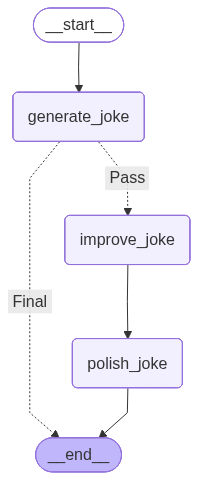

In [11]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(State)

workflow.add_node('generate_joke', generate_joke)
workflow.add_node('improve_joke', improve_joke)
workflow.add_node('polish_joke', polish_joke)

workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", chack_punchline, {"Pass": "improve_joke", "Final": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

chain = workflow.compile()

display(Image(chain.get_graph().draw_mermaid_png()))


In [13]:
state = chain.invoke({'topic':'cats'})
print('Init joke:')
print(state['joke'])
print('\n')
if 'improved_joke' in state:
    print('Improved_joke :')
    print(state['improved_joke'])
    print('\n')
    print('Final_joke :')
    print(state['final_joke'])
else:
    print('Failed quality gate')

Init joke:
Sure, here's a cat-related joke for you:

Why did the cat sit on the computer? 

Because it wanted to be "on" with all the mouse clicks!


Improved_joke :
Sure! Here's a more playful version of the joke:

Why don't cats play poker in the wild?

Because they always end up with a "poker" face!


Final_joke :
Sure, here's an unexpected twist to your joke about cats:

Why did the cat sit on the computer? Because it wanted to keep up with the latest technology!
